In [262]:
import pandas as pd
import seaborn as sns

# 데이터 받아오기
smartphone_df = pd.read_csv('./datasets/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')
display(smartphone_df)
smartphone_df.info()
smartphone_df.shape

# 데이터 개수 : 7500 개
# 총 컬럼 : 16개 -> 범주형(5), 이산형(5) 연속형(6)
# 7500행, 16열

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          6681 non-n

(7500, 16)

In [263]:
# describe 분석
smartphone_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,7500.0,26.568800,5.197108,18.00,22.00,27.000,31.00,35.00
daily_screen_time_hours,7500.0,7.499912,2.609188,3.00,5.22,7.525,9.81,12.00
social_media_hours,7500.0,3.273484,1.585342,0.50,1.91,3.270,4.63,6.00
gaming_hours,7500.0,2.014183,1.146039,0.00,1.02,2.040,2.99,4.00
work_study_hours,7500.0,3.242420,1.600765,0.50,1.85,3.230,4.64,6.00
sleep_hours,7500.0,6.737561,1.283605,4.50,5.63,6.720,7.84,9.00
notifications_per_day,7500.0,134.257333,66.586883,20.00,76.00,134.000,191.00,250.00
app_opens_per_day,7500.0,97.832400,48.423349,15.00,55.00,98.000,140.00,180.00
weekend_screen_time,7500.0,9.243827,2.718281,3.58,6.96,9.260,11.54,14.88
addicted_label,7500.0,0.707733,0.454835,0.00,0.00,1.000,1.00,1.00


#### describe 분석
- 범주형인 addicted_label를 제외한 대부분의 데이터가 매우 균등한 분포를 가진 것으로 나온다.
- 다른 feature들의 표준편차와 중앙값 차이가 소숫점 두자리 정도의 차이를 가지고 있을 때, age는 0.5 정도의 차이가 있는걸 봐선 데이터 분포의 약간의 차이가 있을 것으로 보인다.

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'daily_screen_time_hours'}>,
        <Axes: title={'center': 'social_media_hours'}>],
       [<Axes: title={'center': 'gaming_hours'}>,
        <Axes: title={'center': 'work_study_hours'}>,
        <Axes: title={'center': 'sleep_hours'}>],
       [<Axes: title={'center': 'notifications_per_day'}>,
        <Axes: title={'center': 'app_opens_per_day'}>,
        <Axes: title={'center': 'weekend_screen_time'}>],
       [<Axes: title={'center': 'addicted_label'}>, <Axes: >, <Axes: >]],
      dtype=object)

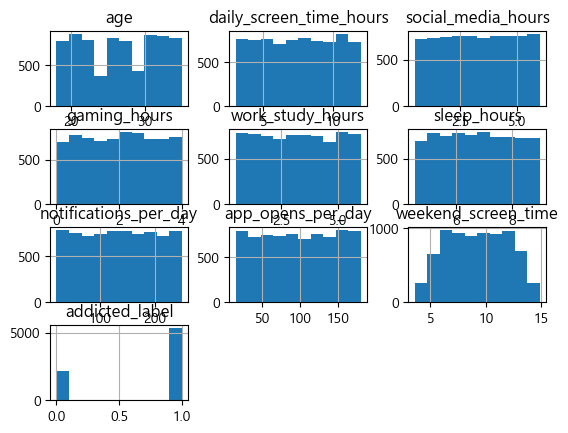

In [244]:
smartphone_df.hist()

#### hist() 시각화

대부분의 데이터가 매우 균등한 분포(균등분포)를 가진 것으로 보인다.
- age에 이상치가 조금 존재하는 것이 확인된다.
- weekend_screen_time가 가장 이상적인 정규분포를 보이고 있다.

In [245]:
# 결측치 확인
smartphone_df.isna().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

#### 결측치 확인
- addiction_level에서 819개의 이상치가 확인된다
- 데이터 확인 결과 addicted_label(중독 여부)가 0인 사람은 addiction_level(중독 수준) 값이 NaN으로 기록되었다.
- 해당 값을 'No Addiction' 으로 대체하여 데이터를 수정하자.

In [264]:
smartphone_df.addiction_level = smartphone_df.addiction_level.fillna('Mild')
smartphone_df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,Mild,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,Mild,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,Mild,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


#### 중복행 확인
- 중복행는 존재하지 않았다.

In [265]:
# 중복행 확인
smartphone_df.duplicated().sum()

np.int64(0)

### 데이터 분석
- 거의 대부분의 데이터가 균등분포의 모습을 하고 있기 때문에 어떠한 데이터와 관계가 있는지 확인해야 한다.
- 지금으로썬 균등분포에 대한 상관관계를 분석할 수 없기에 각 값의 평균값을 addiction_level과 비교해보자.
#### 가설 : sns 이용 시간과 게임 이용 시간이 길수록 중독 수준이 심할까?


In [267]:
import numpy as np
# addiction_level 별로 각 데이터들의 평균값 구하기
sns_mean_df = smartphone_df.groupby('addiction_level')['social_media_hours'].mean().reset_index(drop=False)

game_mean_df = smartphone_df.groupby('addiction_level')['gaming_hours'].mean().reset_index(drop=False)

# 정렬 순서 list
sort_order = ['Mild', 'Moderate', 'Severe']

# 데이터 정렬
for df in [sns_mean_df, game_mean_df]:
    df['addiction_level'] = pd.Categorical(df['addiction_level'], categories=sort_order, ordered=True)
    df.sort_values('addiction_level', inplace=True)
    df.reset_index(drop=True, inplace=True)

display(sns_mean_df)
display(game_mean_df)

,addiction_level,social_media_hours
0,Mild,2.251615
1,Moderate,3.579694
2,Severe,3.832190


,addiction_level,gaming_hours
0,Mild,1.999051
1,Moderate,2.033135
2,Severe,2.005431


### 시각화

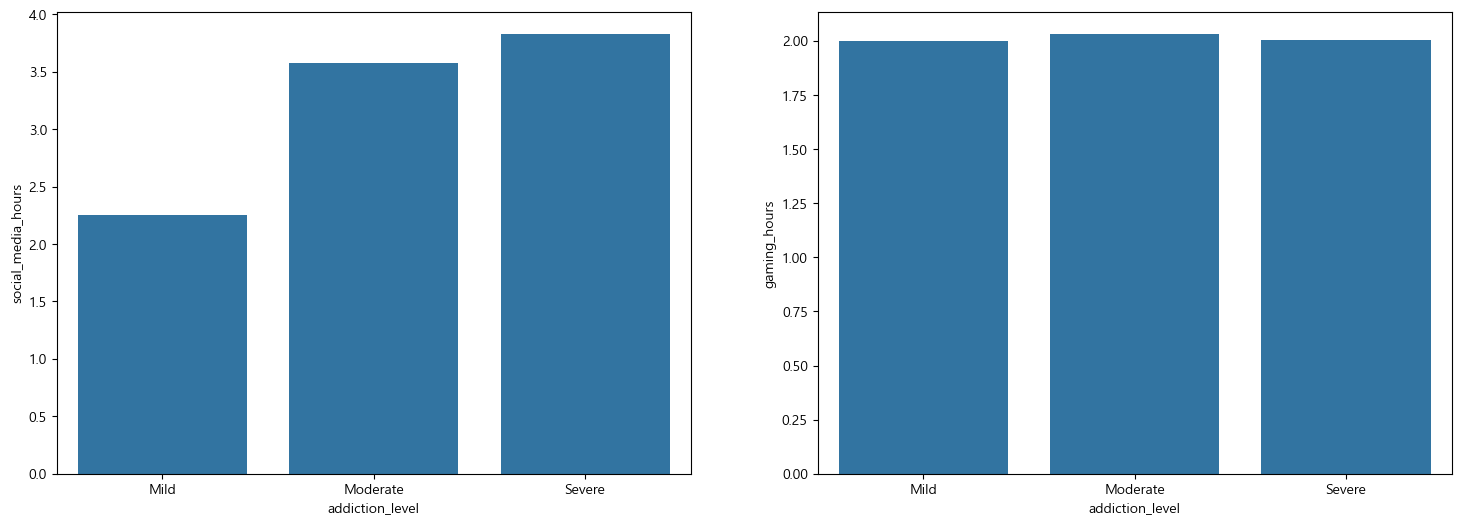

In [268]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=sns_mean_df, x='addiction_level', y='social_media_hours', ax=axes[0])
sns.barplot(data=game_mean_df, x='addiction_level', y='gaming_hours', ax=axes[1])
plt.show()

#### 중독 수준에 따른 SNS·게임 사용 시간 분석 보고서

- "No Addiction" (비중독) 그룹의 경우, SNS 사용 시간의 평균은 2.24시간이며 표준편차는 1.041283이다.
이는 해당 그룹 내 SNS 사용 시간이 평균으로부터 약 1.04시간 퍼져 있음을 의미한다.

  

- "Mild" (경증) 그룹의 경우, SNS 사용 시간의 평균은 2.26시간으로 비중독 그룹과 거의 차이가 없으며, 표준편차 또한 1.008979로 유사한 수준이다.
이는 경증 단계에서는 SNS 사용 패턴이 비중독 그룹과 뚜렷하게 구별되지 않음을 시사한다.

  

- "Moderate" (중등도) 그룹의 SNS 사용 시간 평균은 3.58시간으로, 경증 그룹 대비 약 1.32시간 증가하며 눈에 띄는 차이가 나타난다.
표준편차는 1.589682로 이전 그룹들보다 더 큰 변동성을 보이며, 이 그룹 내에서 사용 시간의 개인차가 커지기 시작함을 나타낸다.

  

- "Severe" (심각) 그룹의 SNS 사용 시간 평균은 3.83시간으로 가장 높으며, 표준편차는 1.568409로 중등도 그룹과 유사한 수준의 변동성을 유지한다.
이는 심각 단계에서도 개인별 편차가 존재하지만, 전반적으로 높은 SNS 사용 시간이 이 그룹의 특징임을 보여준다.

📌 요약하자면, SNS 사용 시간은 중독 수준이 높아질수록 뚜렷하게 증가하는 패턴을 보인다. 특히 Mild에서 Moderate로 넘어가는 구간에서 평균이 급격히 상승하며, 이 지점이 중독 수준과 SNS 사용의 관계에서 핵심적인 분기점으로 해석될 수 있다.

- 게임 사용 시간(gaming_hours) 의 경우, 네 그룹 모두 평균이 약 2.00시간으로 거의 동일하며, 표준편차 또한 1.13~1.16 범위 내에서 거의 차이가 없다.
이는 게임 사용 시간은 중독 수준과 무관하게 일정하게 유지됨을 나타내며, 스마트폰 중독의 주요 요인이 게임보다는 SNS와 더 밀접하게 연관되어 있을 가능성을 시사한다.

📌 두 변수를 종합하면, 스마트폰 중독 수준의 심화는 게임이 아닌 SNS 사용 시간 증가와 강한 연관성을 가지며, 중독 예방 및 개입 전략 수립 시 SNS 사용 패턴에 집중할 필요가 있다.

#### 추가 확인 : 그럼 중독 수준에 가장 연관이 큰 값은 뭘까?

In [269]:
# 하루 평균 이용 시간 평균
daily_mean_df = smartphone_df.groupby('addiction_level')['daily_screen_time_hours'].mean().reset_index(drop=False)

# 수면 시간
sleep_mean_df = smartphone_df.groupby('addiction_level')['sleep_hours'].mean().reset_index(drop=False)

# 알림 확인 수
notifications_mean_df = smartphone_df.groupby('addiction_level')['notifications_per_day'].mean().reset_index(drop=False)

# 주간 이용 시간
weekend_mean_df = smartphone_df.groupby('addiction_level')['weekend_screen_time'].mean().reset_index(drop=False)

# 각 값들을 정렬
for df in [daily_mean_df, sleep_mean_df, notifications_mean_df, weekend_mean_df]:
    df['addiction_level'] = pd.Categorical(df['addiction_level'], categories=sort_order, ordered=True)
    df.sort_values('addiction_level', inplace=True)
    df.reset_index(drop=True, inplace=True)

display(daily_mean_df)

,addiction_level,daily_screen_time_hours
0,Mild,5.156861
1,Moderate,8.351427
2,Severe,8.604560


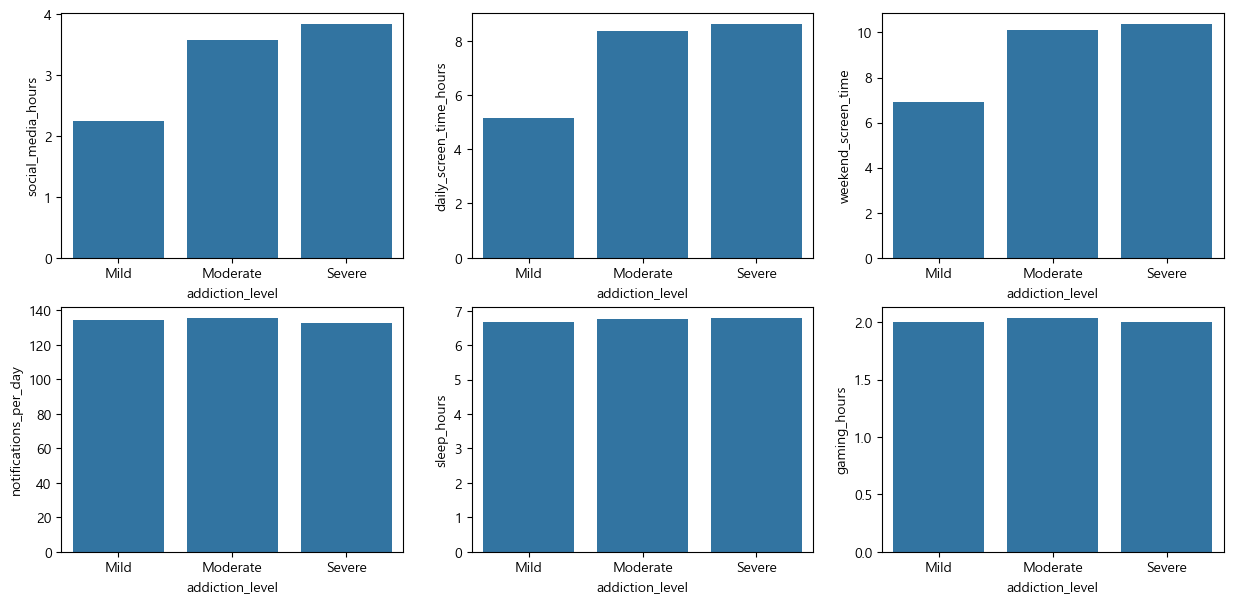

In [270]:
plt.rcParams['font.family'] = 'Malgun Gothic'
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

sns.barplot(data=sns_mean_df, x='addiction_level', y='social_media_hours', ax=axes[0][0])
sns.barplot(data=daily_mean_df, x='addiction_level', y='daily_screen_time_hours', ax=axes[0][1])
sns.barplot(data=weekend_mean_df, x='addiction_level', y='weekend_screen_time', ax=axes[0][2])
sns.barplot(data=notifications_mean_df, x='addiction_level', y='notifications_per_day', ax=axes[1][0])
sns.barplot(data=sleep_mean_df, x='addiction_level', y='sleep_hours', ax=axes[1][1])
sns.barplot(data=game_mean_df, x='addiction_level', y='gaming_hours', ax=axes[1][2])
plt.show()

#### 중독 수준에 따른 스마트폰 사용 패턴 종합 분석 보고서
---

**[중독 수준과 연관된 변수]**

- **SNS 사용 시간(`social_media_hours`)** 의 경우, No Addiction(2.24시간)과 Mild(2.26시간) 그룹은 평균이 거의 동일하지만, Moderate(3.58시간)와 Severe(3.83시간) 그룹에서 평균이 급격히 상승한다. 표준편차 또한 No Addiction(1.041)에서 Moderate(1.590)로 커지며, Mild에서 Moderate로 넘어가는 구간이 SNS 사용 패턴의 핵심 분기점임을 시사한다.

- **하루 스크린 타임(`daily_screen_time_hours`)** 의 경우, No Addiction 그룹의 평균은 4.52시간이며 표준편차는 0.860으로 그룹 내 편차가 가장 작다. Mild(5.54시간), Moderate(8.35시간), Severe(8.60시간)으로 중독 수준이 높아질수록 평균이 뚜렷하게 증가하며, 표준편차 역시 Moderate(2.313)와 Severe(2.449)에서 크게 벌어진다. 이는 중등도 이상 그룹에서는 개인별 스크린 타임의 편차도 함께 커짐을 의미한다.

- **주말 스크린 타임(`weekend_screen_time`)** 도 동일한 패턴을 보인다. No Addiction(6.23시간)에서 Severe(10.36시간)로 약 4시간 이상 증가하며, 표준편차 또한 No Addiction(1.141)에서 Severe(2.564)로 두 배 이상 커진다. 주말에도 스마트폰 사용을 조절하지 못하는 경향이 중독 수준과 비례함을 보여준다.

---

**[중독 수준과 무관한 변수]**

- **하루 알림 수(`notifications_per_day`)** 의 경우, 네 그룹 모두 평균이 132-135건으로 거의 동일하며 표준편차도 65-68 범위 내에서 차이가 없다. 이는 알림 수는 사용자가 능동적으로 설정하는 값이 아니라 앱 설치 수에 따라 결정되는 경향이 있어, 중독 수준과의 관련성이 낮은 것으로 해석된다.

- **수면 시간(`sleep_hours`)** 의 경우에도 네 그룹 평균이 6.66-6.78시간으로 매우 유사하고 표준편차도 1.27-1.29로 거의 동일하다. 일반적으로 스마트폰 과사용이 수면에 영향을 준다고 알려져 있으나, 이 데이터에서는 중독 수준과 수면 시간 사이의 뚜렷한 관계가 나타나지 않는다.

- **게임 시간(`gaming_hours`)** 역시 전 그룹에서 평균 약 2.00시간, 표준편차 약 1.14로 일정하다. 스마트폰 중독이 게임 사용 시간 증가로 이어지지는 않으며, 게임은 중독 수준과 독립적인 사용 패턴을 가짐을 나타낸다.

---

📌 **종합하면,** 스마트폰 중독 수준의 심화는 **SNS 사용 시간, 하루 스크린 타임, 주말 스크린 타임** 세 변수와 뚜렷한 비례 관계를 보이는 반면, **알림 수·수면 시간·게임 시간**은 중독 수준과 무관하게 전 그룹에서 일정하게 유지된다. 이는 스마트폰 중독이 단순한 기기 사용 전반의 증가가 아니라, **SNS를 중심으로 한 특정 사용 행태의 심화**와 관련이 깊음을 시사한다.